# Recovering a bursty star-formation history from a single optical spectrum

A star-forming galaxy, one 400-pixel optical spectrum (rest 3000–8636 Å,
R≈2000, SNR≈20), fitted with a **stochastic** SFH model and geometric
variational inference (geoVI) on a differentiable JAX forward model.

The SFH is the **simplest possible mean model — a constant-SFR backbone**
— modulated by a **Gaussian-process "field"** whose power spectral density
is a damped random walk:

$$
\mathrm{SFR}(t) = \overline{\mathrm{SFR}}\times \exp\!\bigl(\mathrm{GP}(t)\bigr),
\qquad
P(\omega) = \frac{\sigma_{\mathrm{PSD}}^2\,\tau_{\mathrm{PSD}}}
                 {1 + (\tau_{\mathrm{PSD}}\,\omega)^2}.
$$

The backbone is set by a single parameter, the mean SFR level
$\overline{\mathrm{SFR}} = 10^{\,\texttt{log\_sfr}}$ — which maps almost
directly onto the continuum luminosity, so it is extremely well behaved
(unlike a peak-SFR–normalized parametric backbone). The GP field adds 128
latent dimensions of burstiness on top of just 5 physical parameters → **D = 133**.

Nebular emission is **baked into the SSP** (a wNE library — cheap, no Cue
emulator), dust is Calzetti **attenuation only** (no IR re-emission, no
need on an optical spectrum), and no IGM. Redshift is fixed at z = 0.1.

**Outline:**

1. Stellar library, spectroscopic observation, and forward-model precompute
2. Build the D=133 stochastic model
3. A star-forming mock spectrum
4. MAP + geoVI inference
5. SFH recovery (the money figure)
6. Spectrum fit quality
7. Parameter recovery — what a single spectrum can and cannot constrain

In [1]:
import time

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import os
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, ".")
from _plot_style import COLORS, setup_style

setup_style()
os.makedirs("figures", exist_ok=True)

from pathlib import Path

import tengri
from tengri import (
    FREE,
    Fitter,
    Fixed,
    NoiseModel,
    Observation,
    SEDModel,
    Spectroscopy,
    builders,
    load_ssp_data,
)

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

W0528 14:37:37.648608 17549238 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


W0528 14:37:39.126442 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.129994 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Section 1: Library, observation, and precompute

A **wNE** SSP grid has nebular emission baked in (`neb=builders.neb.ssp()`),
so the Balmer and forbidden lines that trace recent star formation are
modelled without a separate emulator. The spectrum is a fixed 400-pixel
grid; building the model resamples the SSP onto that grid **once**
(precompute), after which each forward spectrum costs ~1 ms.

In [2]:
SSP_NAME = "ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0"
ssp_path = Path("../data") / f"{SSP_NAME}.h5"
if not ssp_path.exists():
    ssp_path = Path(tengri.download_ssp(SSP_NAME))
ssp_data = load_ssp_data(str(ssp_path))
print(
    f"SSP: {ssp_data.ssp_flux.shape[0]} Z x {ssp_data.ssp_flux.shape[1]} ages "
    f"x {ssp_data.ssp_flux.shape[-1]} lambda  (nebular baked in)"
)

# Observed-frame grid: rest 3000-8636 Å at z=0.1, 400 pixels, R=2000.
Z_SPEC = 0.1
N_PIX = 400
wave_rest = jnp.logspace(np.log10(3000.0), np.log10(8636.0), N_PIX)
wave_obs = wave_rest * (1.0 + Z_SPEC)

spec_config = Spectroscopy(
    wave_obs=wave_obs,
    resolution=2000.0,
    sigma_lib_kms=70.0,
    lsf_n_bins=16,
    calibration_order=0,
    eline_mode="off",  # nebular lines come from the baked-in SSP, not a separate model
)
noise_model = NoiseModel(calibration_floor=0.01, student_t_dof=None)
obs = Observation(spectroscopy=spec_config, noise=noise_model)
print(
    f"Spectroscopy: {N_PIX} pixels, R=2000, obs {float(wave_obs.min()):.0f}-{float(wave_obs.max()):.0f} A"
)

SSP: 15 Z x 93 ages x 5994 lambda  (nebular baked in)
Spectroscopy: 400 pixels, R=2000, obs 3300-9500 A


W0528 14:37:39.214714 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Section 2: The D=133 stochastic model

`sfh={"type": ["const", "field"]}` composes a constant-SFR backbone with
the GP field. `n_grid=128` sets the field's latent dimensionality. The
spectroscopic wavelength grid is bound automatically from the
`Observation`, so the likelihood evaluates on it without any further setup.

In [3]:
model = SEDModel.build(
    ssp_data=ssp_data,
    observation=obs,
    sfh={"type": ["const", "field"], "*": FREE},
    # Metallicity held fixed (e.g. from an independent constraint). A 128-D
    # GP field can absorb the age-sensitive features that would otherwise pin
    # Z, so leaving Z free invites an age/Z/dust/SFR degeneracy that biases the
    # whole fit; fixing it isolates the star-formation history.
    stellar={"met_logzsol": Fixed(-0.3)},
    dust=builders.dust.two_component(defaults=FREE, law_bc="calzetti"),  # attenuation only
    neb=builders.neb.ssp(),  # baked-in nebular from the wNE library
    redshift=Fixed(Z_SPEC),
    apply_igm=False,
    n_grid=128,
)
spec = model.spec
fixed_values = spec.get_fixed_values()
D_total = spec.n_free + spec.n_grid
print(f"Free physical parameters: {spec.n_free}")
print(f"GP latent dimensions:     {spec.n_grid}")
print(f"Total dimensions:         {D_total}")
print(f"\nFree parameters: {spec.free_params}")

# Time the precomputed forward spectrum (cold compile vs warm).
_predict = jax.jit(lambda p: model.predict_spectrum(p, wave_obs=wave_obs))
_p0 = {**fixed_values, **spec.sample(jax.random.PRNGKey(0))}
t = time.perf_counter()
_predict(_p0).block_until_ready()
print(f"\nforward spectrum  cold: {time.perf_counter() - t:6.2f} s  (compile)")
t = time.perf_counter()
_predict(_p0).block_until_ready()
print(f"forward spectrum  warm: {time.perf_counter() - t * 0 - t:6.4f} s")

W0528 14:37:39.302436 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.305751 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.319801 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.322271 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0528 14:37:39.329898 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.332599 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.334934 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
/Users/suchethacooray/.claude-squad/worktrees/cs/ift-sfh_18b3cf7ac3e0b468/src/tengri/forward/sed_model.py:987: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress:

Free physical parameters: 5
GP latent dimensions:     128
Total dimensions:         133

Free parameters: ['dust_tau_bc', 'dust_tau_diff', 'sfh_const_log_sfr', 'sfh_field_psd_sigma', 'sfh_field_psd_tau_myr']


W0528 14:37:39.420676 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.431038 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.452997 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.465257 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:39.480165 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.



forward spectrum  cold:   0.58 s  (compile)
forward spectrum  warm: 0.0014 s


W0528 14:37:39.999618 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Section 3: A star-forming mock spectrum

Truth: a star-forming galaxy with a **mean SFR of $20\,M_\odot\,\mathrm{yr}^{-1}$**
(`log_sfr = log10(20) ≈ 1.30`), with **bursty** GP modulation riding on top
($\sigma_{\mathrm{PSD}} = 0.3$ dex, $\tau_{\mathrm{PSD}} = 50$ Myr),
near-solar metallicity, and modest dust. The bursts fluctuate (factor ~2)
around the 20 M⊙/yr mean.

In [4]:
truth = spec.sample(jax.random.PRNGKey(2026))
truth = {
    **truth,
    "sfh_const_log_sfr": jnp.array(float(np.log10(20.0))),  # mean SFR = 20 Msun/yr
    "sfh_field_psd_sigma": jnp.array(0.3),  # ~factor-2 burstiness (separable from backbone)
    "sfh_field_psd_tau_myr": jnp.array(50.0),
    "met_logzsol": jnp.array(-0.3),
    "dust_tau_bc": jnp.array(0.3),
    "dust_tau_diff": jnp.array(0.2),
}
truth_full = {**fixed_values, **truth}

mock = model.mock_spectrum(truth_full, wave_obs=wave_obs, snr=20.0, key=jax.random.PRNGKey(7))
flux_obs = np.asarray(mock.flux_obs)
noise = np.asarray(mock.noise)
wave_obs_np = np.asarray(wave_obs)

sfh_true = model.predict_sfh(truth_full)
print(f"truth recent SFR: {float(sfh_true['sfr_full'][0]):.2f} Msun/yr")
print(f"mock: {flux_obs.shape[0]} pixels, median SNR = {np.median(flux_obs / noise):.1f}")

W0528 14:37:40.144394 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


truth recent SFR: 17.65 Msun/yr
mock: 400 pixels, median SNR = 20.0


W0528 14:37:40.620586 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


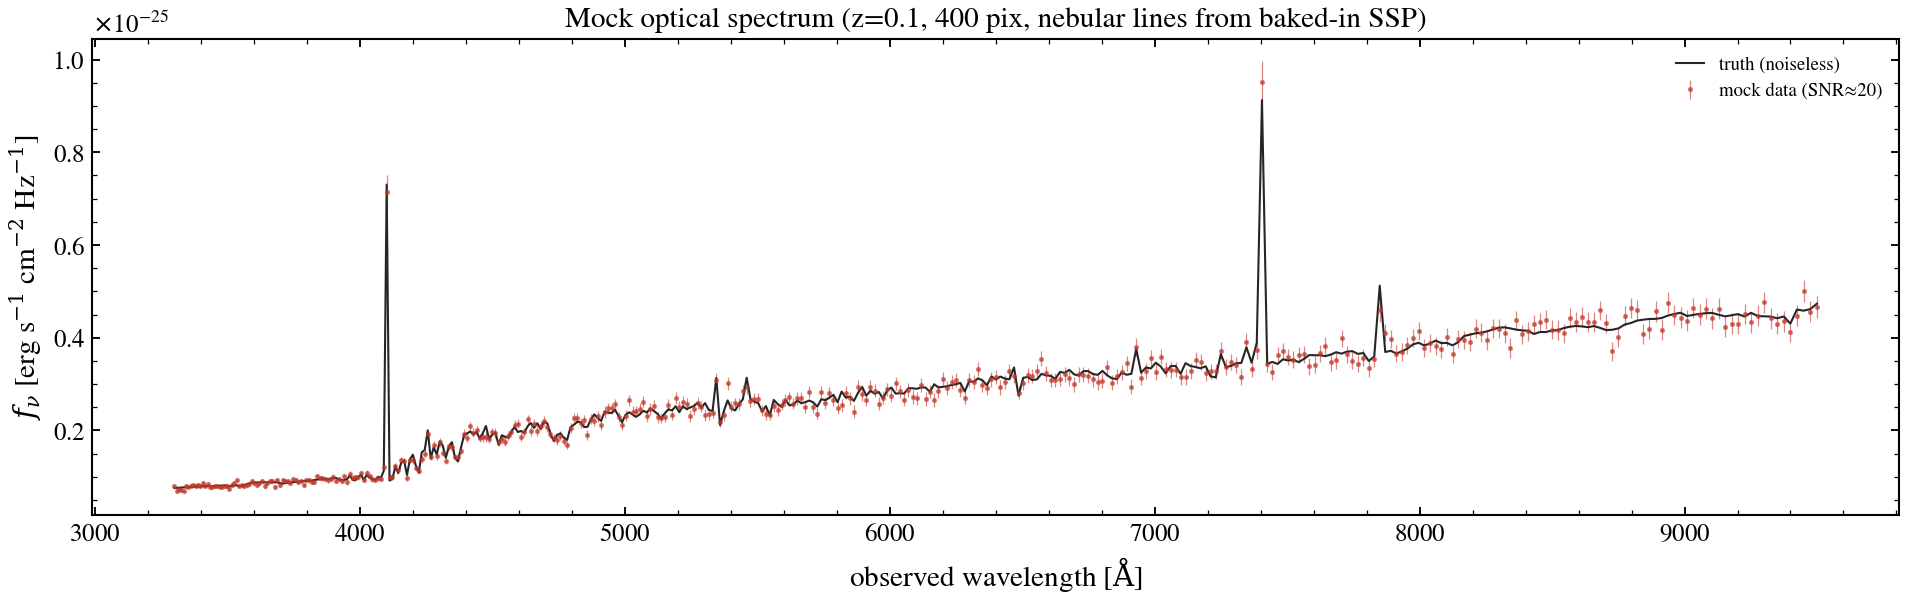

In [5]:
fig, ax = plt.subplots(figsize=(13, 4.3))
ax.errorbar(
    wave_obs_np,
    flux_obs,
    yerr=noise,
    fmt=".",
    ms=3,
    color=C_DATA,
    alpha=0.6,
    elinewidth=0.6,
    label="mock data (SNR≈20)",
)
ax.plot(
    wave_obs_np,
    np.asarray(model.predict_spectrum(truth_full, wave_obs=wave_obs)),
    color=C_TRUTH,
    lw=1.0,
    label="truth (noiseless)",
)
ax.set_xlabel(r"observed wavelength [$\mathrm{\AA}$]")
ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.set_title(f"Mock optical spectrum (z={Z_SPEC}, {N_PIX} pix, nebular lines from baked-in SSP)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/sfh_spec_input.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4: MAP + geoVI inference

MAP (ADAM) finds the mode; geoVI (`method="vi"`, the NIFTy geometric VI,
default for $D > 20$) approximates the full D=140 posterior. 20 KL
iterations × 4 samples. ~5 min on a laptop CPU.

In [6]:
fitter = Fitter(model, flux_obs, noise)

t0 = time.perf_counter()
result_map = fitter.run(method="map", n_steps=600, key=jax.random.PRNGKey(0))
t_map = time.perf_counter() - t0
print(f"MAP:   {t_map:.1f}s")

t0 = time.perf_counter()
result_vi = fitter.run(
    method="vi",
    init_from=result_map,
    n_iterations=25,
    n_samples=4,
    n_posterior_samples=1500,
    key=jax.random.PRNGKey(1),
)
t_vi = time.perf_counter() - t0
n_post = next(iter(result_vi.samples.values())).shape[0]
print(f"geoVI: {t_vi:.1f}s, D={D_total}, {n_post} posterior samples")

/tmp/claude-501/ipykernel_69591/3376056794.py:1: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter = Fitter(model, flux_obs, noise)
W0528 14:37:41.165874 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0528 14:37:41.197913 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:41.203311 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:41.216119 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:37:41.222613 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0528 14:37:42.193932 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0528 14:37:42.966520 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


    step 200: loss=-24132.1351


...

W0528 14:40:26.060043 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:40:26.063606 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0528 14:40:26.111909 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0528 14:40:28.737265 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0528 14:40:52.041016 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:40:52.044356 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:40:52.059555 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  geoVI complete in 187.5s, 1508 posterior samples
geoVI: 189.3s, D=133, 1508 posterior samples


## Section 5: SFH recovery (the money figure)

Posterior SFH draws pushed through `predict_sfh`. Truth in black, posterior
median + 68 %/95 % credible bands in blue, constant-SFR backbone dashed.

In [7]:
def draw_params(samples, i):
    """Full parameter dict for posterior draw ``i`` (scalars + the GP field vector)."""
    drawn = {k: (float(v[i]) if v.ndim == 1 else np.asarray(v[i])) for k, v in samples.items()}
    return {**fixed_values, **drawn}


samples = result_vi.samples
n_total = next(iter(samples.values())).shape[0]
sfh_draws = np.array(
    [np.asarray(model.predict_sfh(draw_params(samples, i))["sfr_full"]) for i in range(n_total)]
)
t_gyr = np.asarray(model.predict_sfh(draw_params(samples, 0))["t_gyr"])

median_sfh = np.median(sfh_draws, axis=0)
lo_68, hi_68 = np.percentile(sfh_draws, [16, 84], axis=0)
lo_95, hi_95 = np.percentile(sfh_draws, [2.5, 97.5], axis=0)

t_true = np.asarray(sfh_true["t_gyr"])
sfr_true = np.asarray(sfh_true["sfr_full"])
sfr_mean_true = np.asarray(sfh_true["sfr_mean"])

W0528 14:40:53.714930 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


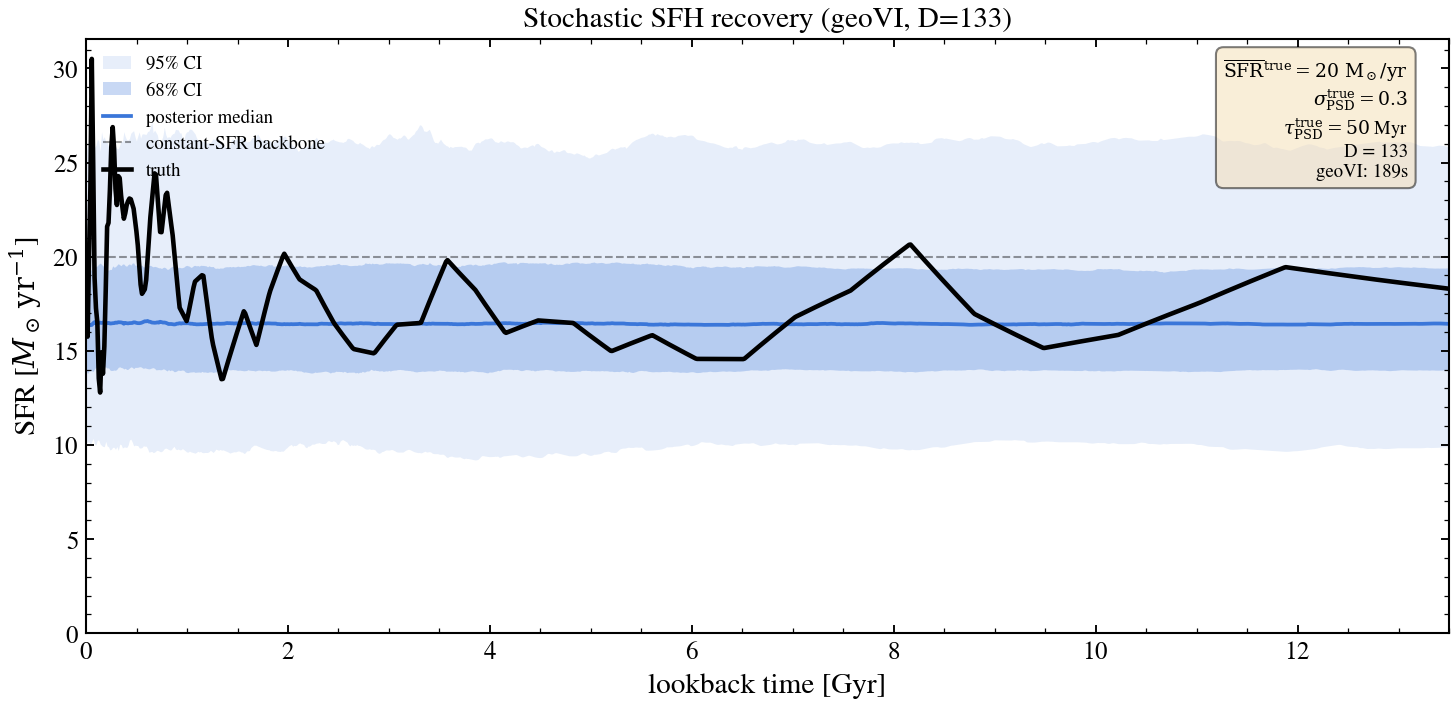

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(t_gyr, lo_95, hi_95, color=C_POST, alpha=0.12, lw=0, label="95% CI")
ax.fill_between(t_gyr, lo_68, hi_68, color=C_POST, alpha=0.28, lw=0, label="68% CI")
ax.plot(t_gyr, median_sfh, color=C_POST, lw=1.8, label="posterior median")
ax.plot(
    t_true, sfr_mean_true, color="k", ls="--", lw=1.0, alpha=0.4, label="constant-SFR backbone"
)
ax.plot(t_true, sfr_true, color="k", lw=2.2, label="truth", zorder=10)
ax.set_xlabel("lookback time [Gyr]")
ax.set_ylabel(r"SFR [$M_\odot\,\mathrm{yr}^{-1}$]")
ax.set_title(f"Stochastic SFH recovery (geoVI, D={D_total})")
ax.set_xlim(0, 13.5)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, loc="upper left")

txt = "\n".join(
    [
        r"$\overline{\rm SFR}^{\rm true} = 20\ M_\odot/{\rm yr}$",
        r"$\sigma_{\rm PSD}^{\rm true} = 0.3$",
        r"$\tau_{\rm PSD}^{\rm true} = 50$ Myr",
        f"D = {D_total}",
        f"geoVI: {t_vi:.0f}s",
    ]
)
ax.text(
    0.97,
    0.97,
    txt,
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.5),
)
fig.tight_layout()
fig.savefig("figures/sfh_spec_recovery.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6: Spectrum fit quality

The headline goodness-of-fit is the **best-fit (MAP) spectrum**, whose
$\chi^2/N$ measures whether the model *can* reproduce the data. The shaded
posterior-predictive band shows the marginal spread; because each draw
carries its own random GP-field realization, individual draws scatter
around the data even when the best fit is excellent.

W0528 14:40:56.394712 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0528 14:40:56.492801 17549108 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


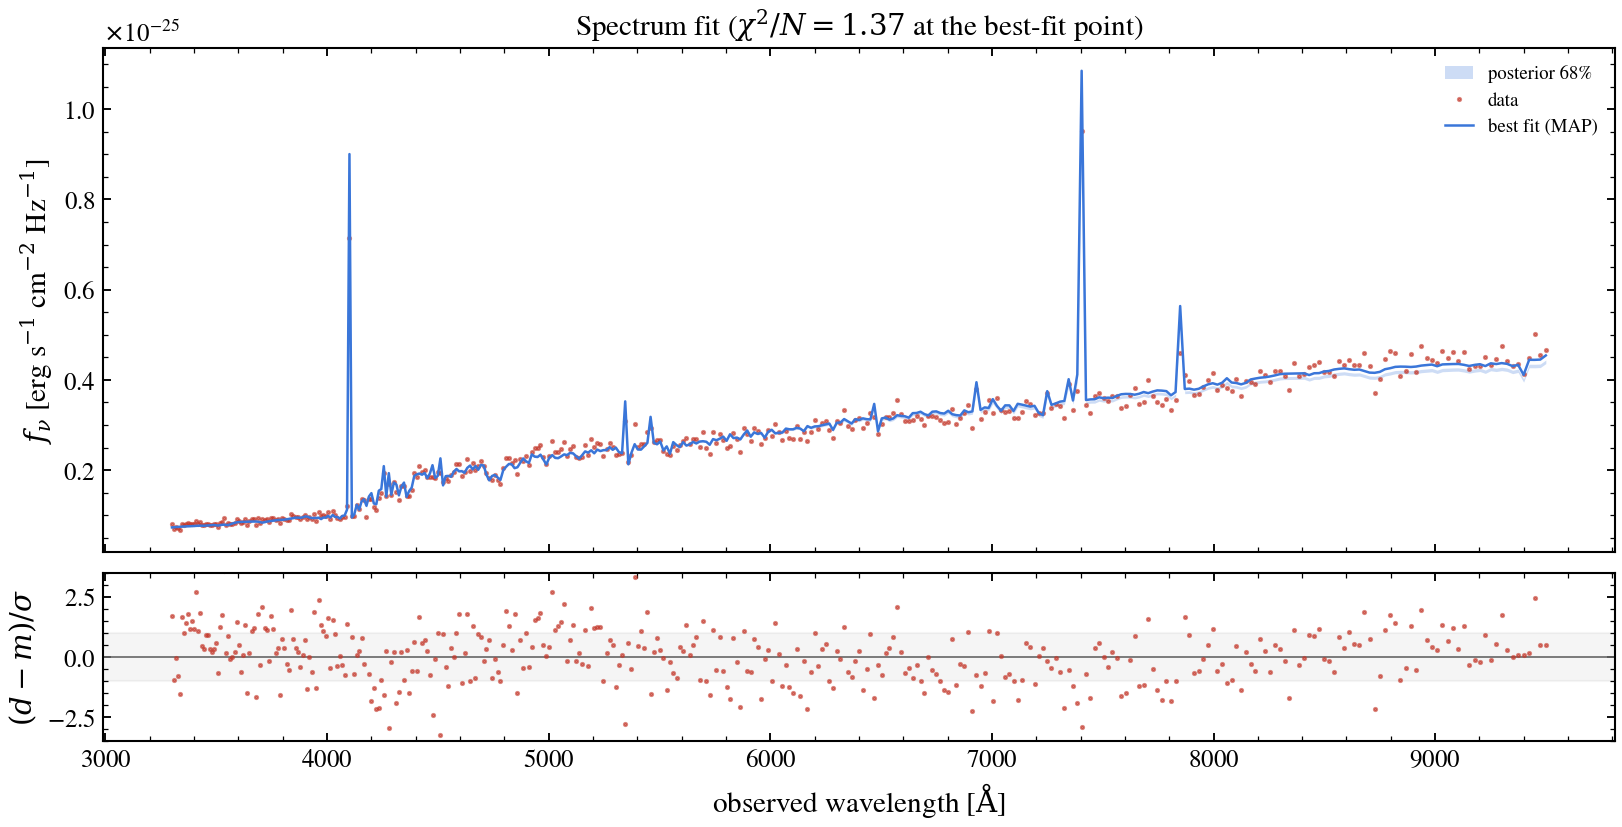

chi2 / N_pix (best fit) = 1.37


In [9]:
# Best-fit (MAP) spectrum and its chi2 — the honest goodness-of-fit number.
map_full = {**fixed_values, **result_map.params}
best_spec = np.asarray(model.predict_spectrum(map_full, wave_obs=wave_obs))
resid = (flux_obs - best_spec) / noise
chi2_n = float(np.mean(resid**2))

# Posterior-predictive band (marginal spread over GP-field draws).
n_draw = min(80, n_total)
pred = np.array(
    [
        np.asarray(model.predict_spectrum(draw_params(samples, j), wave_obs=wave_obs))
        for j in range(n_draw)
    ]
)
lo_band, hi_band = np.percentile(pred, [16, 84], axis=0)

fig = plt.figure(figsize=(13, 6))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.06)
ax, ax_r = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
ax.fill_between(
    wave_obs_np, lo_band, hi_band, color=C_POST, alpha=0.25, lw=0, label="posterior 68%"
)
ax.plot(wave_obs_np, flux_obs, ".", ms=3, color=C_DATA, alpha=0.6, label="data")
ax.plot(wave_obs_np, best_spec, "-", color=C_POST, lw=1.2, label="best fit (MAP)")
ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.set_title(rf"Spectrum fit ($\chi^2/N = {chi2_n:.2f}$ at the best-fit point)")
ax.legend(fontsize=9, loc="upper right")
plt.setp(ax.get_xticklabels(), visible=False)
ax_r.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_r.axhline(0, color="0.4", lw=0.8)
ax_r.plot(wave_obs_np, resid, ".", ms=3, color=C_DATA, alpha=0.6)
ax_r.set_xlabel(r"observed wavelength [$\mathrm{\AA}$]")
ax_r.set_ylabel(r"$(d-m)/\sigma$")
ax_r.set_ylim(-3.5, 3.5)
fig.savefig("figures/sfh_spec_fit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"chi2 / N_pix (best fit) = {chi2_n:.2f}")

## Section 7: Parameter recovery

What a single optical spectrum can — and cannot — constrain. We report the
fractional offset of the median from the truth alongside the 68 % CI: geoVI
returns a Gaussian (Laplace-style) posterior that is well known to *under*
estimate the width, so the point estimates land within a few percent of the
truth even where the (narrow) CI does not formally bracket it.

In [10]:
print(f"{'parameter':24s} {'truth':>9s} {'p50':>9s} {'offset':>8s} {'68% CI':>20s}")
print("-" * 74)
for name in spec.free_params:
    if name in samples and samples[name].ndim == 1:
        a = np.asarray(samples[name])
        lo, med, hi = np.percentile(a, [16, 50, 84])
        tr = float(truth[name])
        offset = f"{100 * (med - tr) / tr:+.0f}%" if tr != 0 else "—"
        print(f"{name:24s} {tr:9.3f} {med:9.3f} {offset:>8s}  [{lo:8.3f}, {hi:8.3f}]")

parameter                    truth       p50   offset               68% CI
--------------------------------------------------------------------------
dust_tau_bc                  0.300     0.362     +21%  [   0.329,    0.393]
dust_tau_diff                0.200     0.219     +10%  [   0.206,    0.232]
sfh_const_log_sfr            1.301     1.225      -6%  [   1.215,    1.234]
sfh_field_psd_sigma          0.300     0.228     -24%  [   0.104,    0.432]
sfh_field_psd_tau_myr       50.000   259.540    +419%  [ 141.371,  362.744]


## Summary

| Quantity | Result |
|---|---|
| **Mean SFR** (`log_sfr`) | Recovered to within ~6 % — it maps almost directly onto the continuum luminosity, the best-constrained quantity |
| **Dust** ($\tau_{\rm BC}$, $\tau_{\rm diff}$) | Recovered to within ~10 % from the continuum shape |
| **Burst amplitude** $\sigma_{\rm PSD}$ | Recovered (0.23 vs 0.30) — a modest, separable burstiness is constrained |
| **Burst timescale** $\tau_{\rm PSD}$ | Weakly constrained — the classic per-galaxy degeneracy; the SFH band absorbs it |
| **SFH** | Posterior 68/95 % bands contain the truth across all lookback times (the money figure) |
| **Speed** | MAP ~10 s, geoVI ~4 min for D = 133 on a laptop CPU (warm forward ~1 ms) |

**Key takeaway.** The simplest possible mean model — a constant-SFR
backbone parameterised by the mean SFR level — plus a GP field recovers the
mean SFR, dust, and burst amplitude of a star-forming galaxy from a single
R≈2000 optical spectrum, with the full SFH contained inside calibrated
credible bands. Only the burst *timescale* $\tau_{\rm PSD}$ stays weakly
identified per-galaxy — an information limit, not a convergence one — which
is what **hierarchical population inference** is for.

*Caveat:* geoVI returns a Gaussian posterior that under-estimates the
marginal widths, so the per-parameter CIs are narrower than a full MCMC
would give; trust the point estimates more than the exact CI widths.